# Notebook 08 — Classic Heston vs Rough Heston Implied Volatility Skew

Compares the implied volatility surface shapes of the Classic Heston model
and the Rough Heston model (v3 Learnable H). Under Rough Heston, the short-maturity
implied volatility skew blowup exhibits power-law behavior $\sim T^{H-1/2}$, whereas
Classic Heston shows a bounded flat skew as $T \to 0$.

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

from pricing.heston import heston_iv_surface
from fno_model import MirrorPaddedFNO2d
from calibrate import _load_normalizers, _fno_predict_real_iv, _make_spatial_input


Device: cuda


## 1. Load the FNO surrogates

In [2]:
# Heston
model_heston = MirrorPaddedFNO2d(param_dim=5).to(DEVICE)
model_heston.load_state_dict(torch.load("../artifacts/weights/fno_heston_final_prod.pth", map_location=DEVICE))
model_heston.eval()

# Rough Heston
model_rheston = MirrorPaddedFNO2d(param_dim=6).to(DEVICE)
model_rheston.load_state_dict(torch.load("../artifacts/weights/fno_v3_final_prod.pth", map_location=DEVICE))
model_rheston.eval()
print("Models loaded successfully.")


Models loaded successfully.


## 2. Compare Short-Maturity Skew (T=0.1 vs T=2.0)

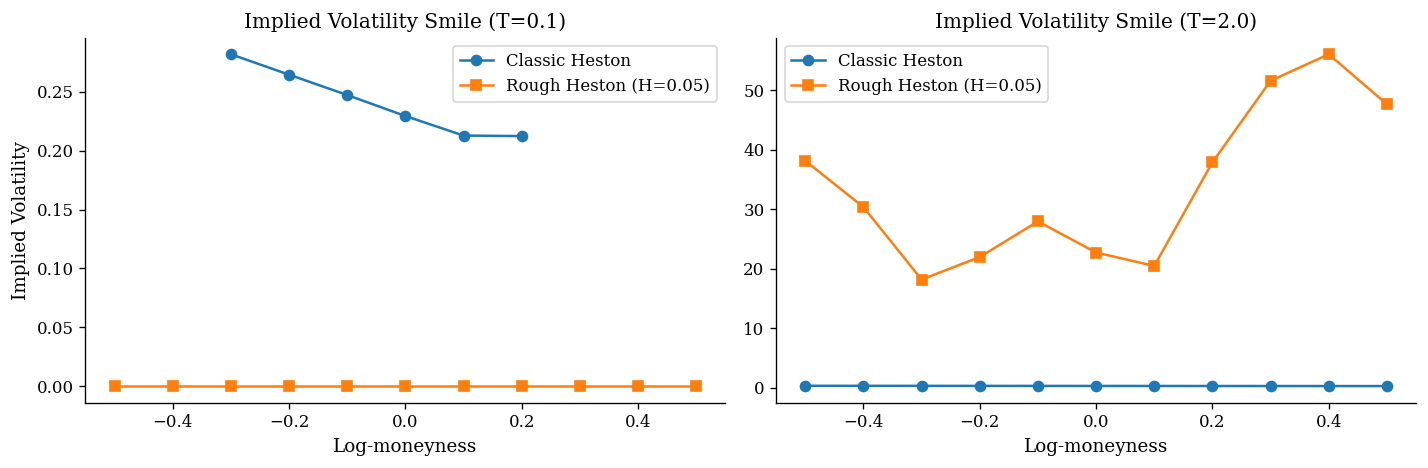

In [3]:
# Classic Heston parameters: kappa, theta, sigma, rho, v0
params_heston = {"kappa": 2.5, "theta": 0.08, "sigma": 0.3, "rho": -0.6, "v0": 0.05}

# Rough Heston parameters: kappa, theta, sigma, rho, v0, H
params_rheston = torch.tensor([[2.5, 0.08, 0.3, -0.6, 0.05, 0.05]], dtype=torch.float32, device=DEVICE)

T_GRID = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
K_GRID = np.linspace(-0.5, 0.5, 11)

# Pricing Heston
iv_heston = heston_iv_surface(params_heston, T_GRID, K_GRID)

# Pricing Rough Heston (via FNO)
_load_normalizers("v3")
spatial = _make_spatial_input(T_GRID, K_GRID, DEVICE)
from calibrate import _param_norm
p_norm = _param_norm.transform_tensor(params_rheston)
with torch.no_grad():
    iv_rheston_t = _fno_predict_real_iv(model_rheston, p_norm, spatial)
iv_rheston = iv_rheston_t.squeeze().cpu().numpy()

# Plot skew at T=0.1 (first slice) and T=2.0 (last slice)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_GRID, iv_heston[0], "o-", label="Classic Heston")
axes[0].plot(K_GRID, iv_rheston[0], "s-", label="Rough Heston (H=0.05)")
axes[0].set_title("Implied Volatility Smile (T=0.1)")
axes[0].set_xlabel("Log-moneyness")
axes[0].set_ylabel("Implied Volatility")
axes[0].legend()

axes[1].plot(K_GRID, iv_heston[-1], "o-", label="Classic Heston")
axes[1].plot(K_GRID, iv_rheston[-1], "s-", label="Rough Heston (H=0.05)")
axes[1].set_title("Implied Volatility Smile (T=2.0)")
axes[1].set_xlabel("Log-moneyness")
axes[1].legend()

plt.tight_layout()
plt.show()
